# Run Deep Dive — Analisis Mendalam Satu Lari

Notebook ini menganalisis satu lari dari file GPX/FIT hasil export Strava.
Data per-titik (sampling per detik) memungkinkan analisis yang jauh lebih dalam dari data rata-rata pipeline.

**Yang dianalisis:**
1. HR & Pace timeline (menit-per-menit)
2. Per-km splits
3. Cardiac drift sejati (paruh 1 vs paruh 2)
4. Distribusi zona HR
5. Prediksi Half Marathon (21.1km) — berapa lama di zona 2 penuh

## 1. Setup & Load GPX

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../src")

import gpxpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

plt.style.use("default")

# ============================================================
# KONFIGURASI — UBAH SESUAI KEBUTUHAN
# ============================================================

# Path ke file GPX
GPX_PATH = Path("../data/gpx/Outdoor_run.gpx")

# Zona HR (Huawei Health / Karvonen method)
# Sesuaikan dengan zona aktual device-mu
HR_ZONES = {
    "Z1 Recovery":         (0,   139),
    "Z2 Basic Aerobic":    (139, 161),   # 139-160 → batas atas 161
    "Z3 Adv Endurance":    (161, 175),   # 161-174 → batas atas 175
    "Z4 Anaerobic":        (175, 199),   # 175-198 → batas atas 199
}
HR_ZONE_COLORS = {
    "Z1 Recovery":         "#74c476",
    "Z2 Basic Aerobic":    "#41ab5d",
    "Z3 Adv Endurance":    "#fd8d3c",
    "Z4 Anaerobic":        "#e31a1c",
}
# Target zone untuk analisis "lari aerobik" (nama key dari HR_ZONES)
AEROBIC_ZONE = "Z2 Basic Aerobic"

# Terrain override manual (None = auto dari elevation data)
# Isi dengan "flat"/"rolling"/"hilly"/"very hilly" kalau auto tidak tepat
# Useful karena phone GPS sering underestimate elevation gain
TERRAIN_OVERRIDE = "rolling"   # contoh: "rolling"

# ============================================================

with open(GPX_PATH, "r", encoding="utf-8") as f:
    gpx = gpxpy.parse(f)

track   = gpx.tracks[0]
segment = track.segments[0]
points  = segment.points

print(f"File   : {GPX_PATH.name}")
print(f"Mulai  : {points[0].time}")
print(f"Selesai: {points[-1].time}")
print(f"Total titik GPS: {len(points):,}")
print(f"\nZona HR yang dipakai:")
for name, (lo, hi) in HR_ZONES.items():
    print(f"  {name:20s}: {lo}–{hi-1} bpm")

File   : Outdoor_run.gpx
Mulai  : 2026-06-13 23:28:13+00:00
Selesai: 2026-06-14 00:52:56+00:00
Total titik GPS: 2,767

Zona HR yang dipakai:
  Z1 Recovery         : 0–138 bpm
  Z2 Basic Aerobic    : 139–160 bpm
  Z3 Adv Endurance    : 161–174 bpm
  Z4 Anaerobic        : 175–198 bpm


## 2. Parse Data per Titik

In [2]:
NS = "{http://www.garmin.com/xmlschemas/TrackPointExtension/v1}"

def haversine(p1, p2):
    """Jarak antar dua titik GPS (meter)."""
    R = 6371000
    lat1, lon1 = radians(p1.latitude), radians(p1.longitude)
    lat2, lon2 = radians(p2.latitude), radians(p2.longitude)
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================================================
# MOVING TIME vs ELAPSED TIME
# Strava & Huawei auto-pause: filter titik berhenti (speed < threshold)
# Ini yang bikin pace kita = pace Strava, bukan elapsed time total
# ============================================================
STOPPED_THRESHOLD = 0.5  # m/s = 1.8 km/h. Titik di bawah ini = berhenti

rows = []
t0 = points[0].time
cum_dist = 0.0
moving_seconds = 0.0
stopped_seconds = 0.0

for i, p in enumerate(points):
    dt = 0
    speed = 0
    if i > 0:
        d = haversine(points[i-1], p)
        dt = (p.time - points[i-1].time).total_seconds()
        speed = d / dt if dt > 0 else 0
        cum_dist += d
        if speed >= STOPPED_THRESHOLD:
            moving_seconds += dt
        else:
            stopped_seconds += dt

    elapsed_s = (p.time - t0).total_seconds()
    hr = cad = None
    if p.extensions:
        hr_el  = p.extensions[0].find(NS + "hr")
        cad_el = p.extensions[0].find(NS + "cad")
        if hr_el  is not None: hr  = int(hr_el.text)
        if cad_el is not None: cad = int(cad_el.text)

    rows.append({
        "elapsed_min"  : elapsed_s / 60,
        "cum_dist_km"  : cum_dist / 1000,
        "speed_mps"    : speed,
        "is_moving"    : speed >= STOPPED_THRESHOLD,
        "hr"           : hr,
        "cad"          : cad,
        "ele"          : p.elevation,
    })

df = pd.DataFrame(rows)

# Smooth pace (rolling 15 titik)
df["speed_smooth"]  = df["speed_mps"].rolling(15, center=True, min_periods=1).mean()
df["pace_min_km"]   = np.where(
    df["speed_smooth"] > 0.1,
    1000 / (df["speed_smooth"] * 60),
    np.nan
)

# Metrik utama
total_dist     = df["cum_dist_km"].iloc[-1]
total_elapsed  = df["elapsed_min"].iloc[-1]
avg_hr         = df["hr"].mean()

# MOVING TIME — cara yang benar (sama seperti Strava/Huawei)
moving_min     = moving_seconds / 60
stopped_min    = stopped_seconds / 60
avg_pace       = moving_min / total_dist   # pace berbasis moving time

print(f"Jarak total      : {total_dist:.2f} km")
print(f"Elapsed time     : {total_elapsed:.1f} menit (termasuk berhenti)")
print(f"Moving time      : {moving_min:.1f} menit (auto-pause, = Strava)")
print(f"Stopped time     : {stopped_min:.1f} menit ({stopped_min/total_elapsed*100:.1f}%)")
print(f"Avg pace (moving): {avg_pace:.2f} min/km  ← ini yang sama dengan Strava")
print(f"Avg HR           : {avg_hr:.1f} bpm")

Jarak total      : 10.19 km
Elapsed time     : 84.7 menit (termasuk berhenti)
Moving time      : 76.7 menit (auto-pause, = Strava)
Stopped time     : 8.1 menit (9.5%)
Avg pace (moving): 7.53 min/km  ← ini yang sama dengan Strava
Avg HR           : 155.1 bpm


## 3. Terrain Analysis (Otomatis + Manual Override)

In [3]:
# ============================================================
# TERRAIN CLASSIFIER (otomatis dari elevation gain)
# Huawei Band 10 + phone GPS: elevation sering underestimate 2-3x
# → Gunakan TERRAIN_OVERRIDE kalau hasil auto tidak sesuai realita
# ============================================================

elevations = [p.elevation for p in points if p.elevation is not None]
total_dist_km = df["cum_dist_km"].iloc[-1]

if len(elevations) > 1:
    gain = sum(max(0, elevations[i+1]-elevations[i]) for i in range(len(elevations)-1))
    loss = sum(max(0, elevations[i]-elevations[i+1]) for i in range(len(elevations)-1))
    gain_per_km = gain / total_dist_km
else:
    gain = loss = gain_per_km = 0

# Threshold otomatis (berbasis phone GPS — biasanya underestimate)
def classify_terrain(gkm):
    if gkm < 10:   return "flat",       "🟢"
    elif gkm < 25: return "rolling",    "🟡"
    elif gkm < 50: return "hilly",      "🟠"
    else:          return "very hilly", "🔴"

terrain_auto, emoji_auto = classify_terrain(gain_per_km)

# Pakai override kalau ada
if TERRAIN_OVERRIDE:
    terrain_final = TERRAIN_OVERRIDE
    source = f"(manual override — auto: {terrain_auto})"
    emoji = {"flat":"🟢","rolling":"🟡","hilly":"🟠","very hilly":"🔴"}.get(TERRAIN_OVERRIDE,"⚪")
else:
    terrain_final = terrain_auto
    source = "(auto dari elevation data)"
    emoji = emoji_auto

print(f"Elevation gain : +{gain:.0f} m total ({gain_per_km:.1f} m/km)")
print(f"Elevation loss : -{loss:.0f} m total")
print(f"Terrain (auto) : {terrain_auto} ({gain_per_km:.1f} m/km)")
print(f"Terrain final  : {emoji} {terrain_final.upper()} {source}")
print()
print("⚠️  CATATAN: Phone GPS elevation sering underestimate 2-3x.")
print("   Kalau terrain terasa lebih berat dari klasifikasi auto,")
print(f"  set TERRAIN_OVERRIDE = 'rolling' (atau hilly) di cell konfigurasi atas.")
print()

# Implikasi cardiac drift untuk terrain ini
drift_note = {
    "flat":       "Flat → drift murni mencerminkan kelelahan kardiovaskular.",
    "rolling":    "Rolling → sebagian drift adalah efek akumulasi tanjakan, bukan pure cardiac drift.",
    "hilly":      "Hilly → drift sangat dipengaruhi terrain. Interpretasi cardiac drift dengan hati-hati.",
    "very hilly": "Very hilly → drift sebagian besar terrain-induced. Cardiac drift sulit diisolasi.",
}
print(f"Implikasi untuk drift: {drift_note.get(terrain_final, '')}")

Elevation gain : +58 m total (5.7 m/km)
Elevation loss : -56 m total
Terrain (auto) : flat (5.7 m/km)
Terrain final  : 🟡 ROLLING (manual override — auto: flat)

⚠️  CATATAN: Phone GPS elevation sering underestimate 2-3x.
   Kalau terrain terasa lebih berat dari klasifikasi auto,
  set TERRAIN_OVERRIDE = 'rolling' (atau hilly) di cell konfigurasi atas.

Implikasi untuk drift: Rolling → sebagian drift adalah efek akumulasi tanjakan, bukan pure cardiac drift.


## 3. Per-km Splits

## 4. Pipeline Connection — MAF Bands dari config.py

Menghubungkan run ini ke metrik pipeline: apakah run ini masuk `in_maf_measure` dan `is_aerobic_session` yang dipakai `compute_maf_trend` & `weekly_summary`?

In [4]:
# ============================================================
# PIPELINE CONNECTION — MAF Bands dari config.py
# Menghubungkan analisis per-run ini ke metrik pipeline
# ============================================================
# Import config dari pipeline
try:
    MAF_MEASURE_LOW  = config.MAF_MEASURE_LOW   # 152
    MAF_MEASURE_HIGH = config.MAF_MEASURE_HIGH  # 160
    AEROBIC_LOW      = config.AEROBIC_SESSION_LOW   # 140
    AEROBIC_HIGH     = config.AEROBIC_SESSION_HIGH  # 160
except:
    # Fallback kalau config tidak bisa diimport
    MAF_MEASURE_LOW, MAF_MEASURE_HIGH = 152, 160
    AEROBIC_LOW,     AEROBIC_HIGH     = 140, 160

hrs = df["hr"].dropna().values
n = len(hrs)

in_maf_measure   = ((hrs >= MAF_MEASURE_LOW) & (hrs <= MAF_MEASURE_HIGH)).sum()
in_aerobic       = ((hrs >= AEROBIC_LOW) & (hrs <= AEROBIC_HIGH)).sum()
is_aerobic_sess  = (avg_hr >= AEROBIC_LOW) and (avg_hr <= AEROBIC_HIGH)

pct_maf_measure  = in_maf_measure / n * 100
pct_aerobic      = in_aerobic / n * 100

print(f"MAF BAND CLASSIFICATION (dari pipeline)")
print(f"{'─'*45}")
print(f"MAF measure band ({MAF_MEASURE_LOW}-{MAF_MEASURE_HIGH} bpm)")
print(f"  Waktu di band  : {in_maf_measure/60:.1f} menit ({pct_maf_measure:.1f}%)")
print(f"  Dipakai untuk  : hitung tren MAF pace (compute_maf_trend)")
print()
print(f"Aerobic session band ({AEROBIC_LOW}-{AEROBIC_HIGH} bpm)")
print(f"  Waktu di band  : {in_aerobic/60:.1f} menit ({pct_aerobic:.1f}%)")
print(f"  Avg HR total   : {avg_hr:.1f} bpm")
print(f"  is_aerobic_sess: {is_aerobic_sess} (avg HR {'masuk' if is_aerobic_sess else 'DI LUAR'} band)")
print()
print(f"{'─'*45}")
print(f"Dengan zona Huawei Health (Karvonen):")
z2_lo, z2_hi = HR_ZONES["Z2 Basic Aerobic"]
in_z2 = ((hrs >= z2_lo) & (hrs < z2_hi)).sum()
print(f"  Z2 Basic Aerobic ({z2_lo}-{z2_hi-1} bpm): {in_z2/60:.1f} menit ({in_z2/n*100:.1f}%)")
print()
print(f"CATATAN: MAF measure band (152-160) ⊂ Z2 Karvonen (139-160)")
print(f"  MAF band = subset lebih ketat untuk mengukur efisiensi aerobik murni")
print(f"  Z2 Karvonen = seluruh zona aerobik dasar (lebih luas)")

MAF BAND CLASSIFICATION (dari pipeline)
─────────────────────────────────────────────
MAF measure band (152-160 bpm)
  Waktu di band  : 23.2 menit (50.4%)
  Dipakai untuk  : hitung tren MAF pace (compute_maf_trend)

Aerobic session band (140-160 bpm)
  Waktu di band  : 32.8 menit (71.1%)
  Avg HR total   : 155.1 bpm
  is_aerobic_sess: True (avg HR masuk band)

─────────────────────────────────────────────
Dengan zona Huawei Health (Karvonen):
  Z2 Basic Aerobic (139-160 bpm): 33.3 menit (72.2%)

CATATAN: MAF measure band (152-160) ⊂ Z2 Karvonen (139-160)
  MAF band = subset lebih ketat untuk mengukur efisiensi aerobik murni
  Z2 Karvonen = seluruh zona aerobik dasar (lebih luas)


Tersimpan: ..\reports\2026\June\runs\2026-06-14_km_splits.png


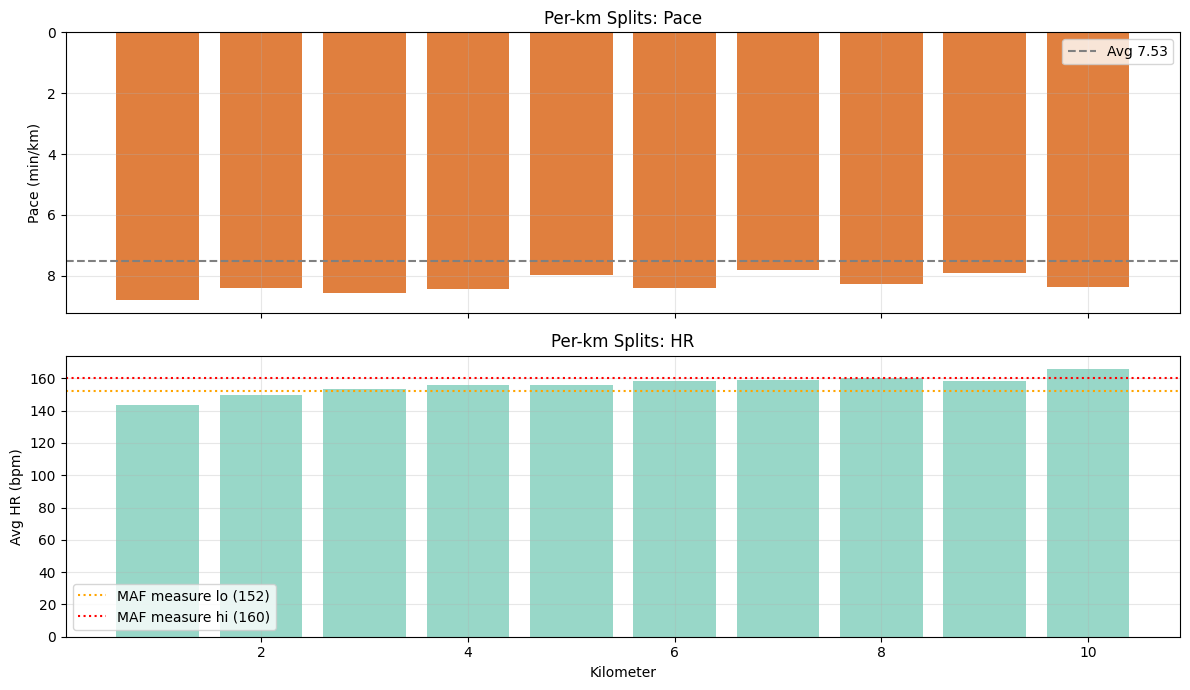


Tabel splits:
 km     pace     avg_hr
  1 8.800000 143.655738
  2 8.400000 149.622951
  3 8.566667 153.311475
  4 8.433333 155.983607
  5 7.966667 155.950820
  6 8.416667 158.491803
  7 7.800000 158.819672
  8 8.266667 160.360656
  9 7.900000 158.278689
 10 8.366667 165.803279


In [5]:
splits = []
km_end_idx = []
prev_t = df["elapsed_min"].iloc[0]
prev_d = 0.0

for km in range(1, int(total_dist) + 1):
    mask = df["cum_dist_km"] >= km
    if not mask.any():
        break
    idx = mask.idxmax()
    t_end = df["elapsed_min"].iloc[idx]
    pace_km = t_end - prev_t
    hr_km   = df.loc[max(0, idx-60):idx, "hr"].mean()
    splits.append({"km": km, "pace": pace_km, "avg_hr": hr_km})
    prev_t = t_end
    km_end_idx.append(idx)

splits_df = pd.DataFrame(splits)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Pace per km
color_pace = ["#2c7fb8" if p <= avg_pace else "#d95f0e" for p in splits_df["pace"]]
axes[0].bar(splits_df["km"], splits_df["pace"], color=color_pace, alpha=0.8)
axes[0].axhline(avg_pace, color="gray", linestyle="--", label=f"Avg {avg_pace:.2f}")
axes[0].set_ylabel("Pace (min/km)")
axes[0].invert_yaxis()
axes[0].set_title("Per-km Splits: Pace")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# HR per km
axes[1].bar(splits_df["km"], splits_df["avg_hr"], color="#7fcdbb", alpha=0.8)
axes[1].axhline(152, color="orange", linestyle=":", label="MAF measure lo (152)")
axes[1].axhline(160, color="red",    linestyle=":", label="MAF measure hi (160)")
axes[1].set_ylabel("Avg HR (bpm)")
axes[1].set_xlabel("Kilometer")
axes[1].set_title("Per-km Splits: HR")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()

# Auto-save
from pathlib import Path
save_dir = Path("../reports/2026/June/runs")
save_dir.mkdir(parents=True, exist_ok=True)
run_date = "2026-06-14"
fig.savefig(save_dir / f"{run_date}_km_splits.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_km_splits.png'}")
plt.show()

print("\nTabel splits:")
print(splits_df.to_string(index=False))

## 4. HR & Pace Timeline (Menit-per-Menit)

Tersimpan: ..\reports\2026\June\runs\2026-06-14_hr_pace_timeline.png


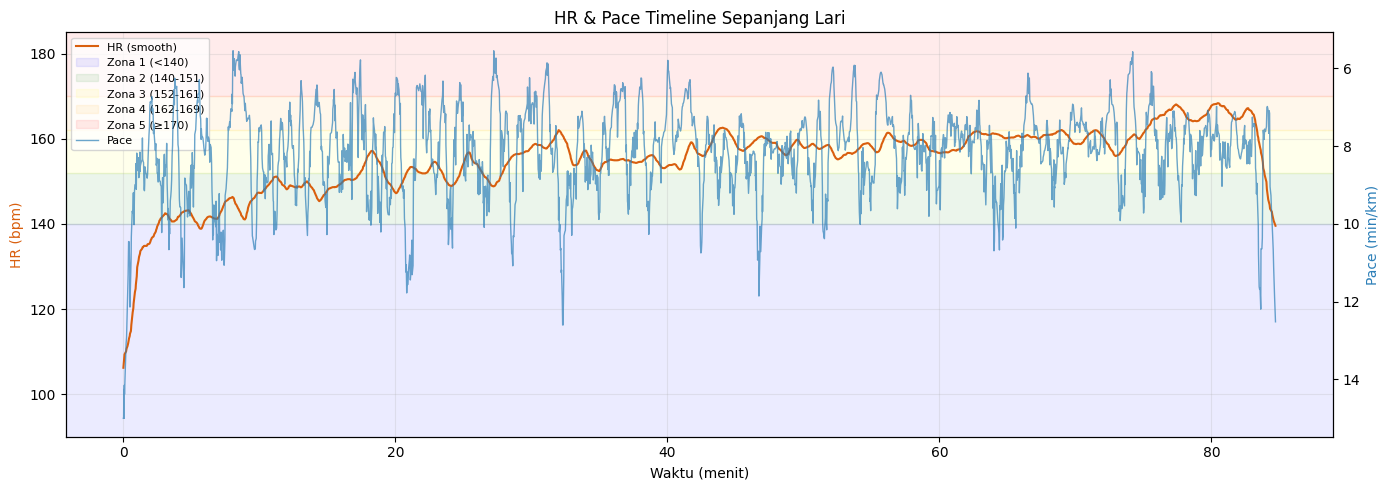

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# HR line dengan warna zona
hr_smooth = df["hr"].rolling(30, center=True, min_periods=1).mean()
ax1.plot(df["elapsed_min"], hr_smooth, color="#d95f0e", linewidth=1.5, label="HR (smooth)")

# Zona HR background
ax1.axhspan(0,   140, alpha=0.08, color="blue",   label="Zona 1 (<140)")
ax1.axhspan(140, 152, alpha=0.08, color="green",  label="Zona 2 (140-151)")
ax1.axhspan(152, 162, alpha=0.08, color="yellow", label="Zona 3 (152-161)")
ax1.axhspan(162, 170, alpha=0.08, color="orange", label="Zona 4 (162-169)")
ax1.axhspan(170, 200, alpha=0.08, color="red",    label="Zona 5 (≥170)")

ax1.set_ylabel("HR (bpm)", color="#d95f0e")
ax1.set_ylim(90, 185)

# Pace line (sumbu kanan) — cap outlier
pace_plot = df["pace_min_km"].clip(5, 15)
ax2 = ax1.twinx()
ax2.plot(df["elapsed_min"], pace_plot, color="#2c7fb8", linewidth=1, alpha=0.7, label="Pace")
ax2.set_ylabel("Pace (min/km)", color="#2c7fb8")
ax2.invert_yaxis()

ax1.set_xlabel("Waktu (menit)")
ax1.set_title("HR & Pace Timeline Sepanjang Lari")
ax1.grid(True, alpha=0.25)

# Gabungkan legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_hr_pace_timeline.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_hr_pace_timeline.png'}")
plt.show()

## 5. Cardiac Drift (Paruh 1 vs Paruh 2)

HR paruh pertama  : 149.9 bpm
HR paruh kedua    : 160.3 bpm
Cardiac drift     : +10.3 bpm

Interpretasi: 🔴 TINGGI — drift besar. HR merangkak naik sepanjang lari (cardiac drift nyata).

Implikasi untuk HM: semakin besar drift, semakin besar HR creep di 21km.
Untuk tetap zona 2 di HM, pace harus lebih pelan dari lari hari ini.

Tersimpan: ..\reports\2026\June\runs\2026-06-14_cardiac_drift.png


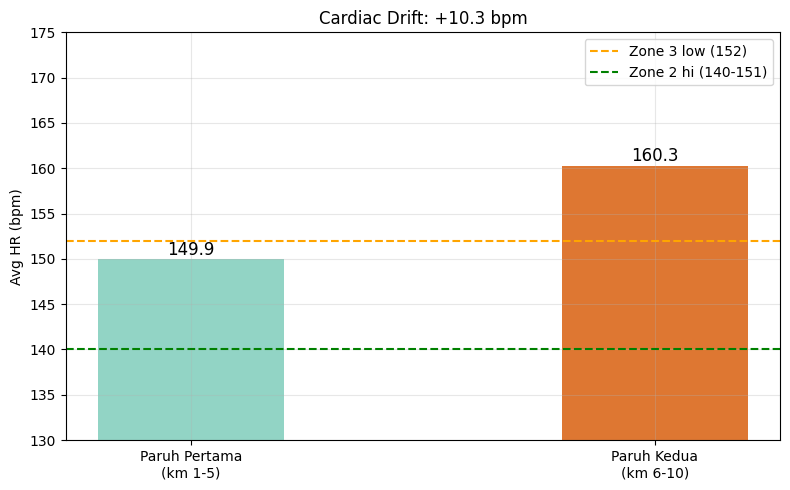

In [7]:
hrs = df["hr"].dropna().values
mid = len(hrs) // 2
hr_first  = hrs[:mid].mean()
hr_second = hrs[mid:].mean()
drift     = hr_second - hr_first

print(f"HR paruh pertama  : {hr_first:.1f} bpm")
print(f"HR paruh kedua    : {hr_second:.1f} bpm")
print(f"Cardiac drift     : {drift:+.1f} bpm")
print()
if drift < 5:
    interp = "✅ BAGUS — drift minimal. Aerobik efisien, tubuh stabil."
elif drift < 10:
    interp = "⚠️ MODERAT — HR naik signifikan. Aerobik masih berkembang."
else:
    interp = "🔴 TINGGI — drift besar. HR merangkak naik sepanjang lari (cardiac drift nyata)."
print(f"Interpretasi: {interp}")
print()
print("Implikasi untuk HM: semakin besar drift, semakin besar HR creep di 21km.")
print("Untuk tetap zona 2 di HM, pace harus lebih pelan dari lari hari ini.")

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Paruh Pertama\n(km 1-5)", "Paruh Kedua\n(km 6-10)"]
vals   = [hr_first, hr_second]
colors = ["#7fcdbb", "#d95f0e"]
bars = ax.bar(labels, vals, color=colors, width=0.4, alpha=0.85)
ax.axhline(152, color="orange", linestyle="--", label="Zone 3 low (152)")
ax.axhline(140, color="green",  linestyle="--", label="Zone 2 hi (140-151)")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}", ha="center", fontsize=12)
ax.set_ylabel("Avg HR (bpm)")
ax.set_title(f"Cardiac Drift: {drift:+.1f} bpm")
ax.legend()
ax.set_ylim(130, 175)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_cardiac_drift.png", dpi=150, bbox_inches="tight")
print(f"\nTersimpan: {save_dir / f'{run_date}_cardiac_drift.png'}")
plt.show()

## 6. Distribusi Zona HR

Tersimpan: ..\reports\2026\June\runs\2026-06-14_zona_hr.png


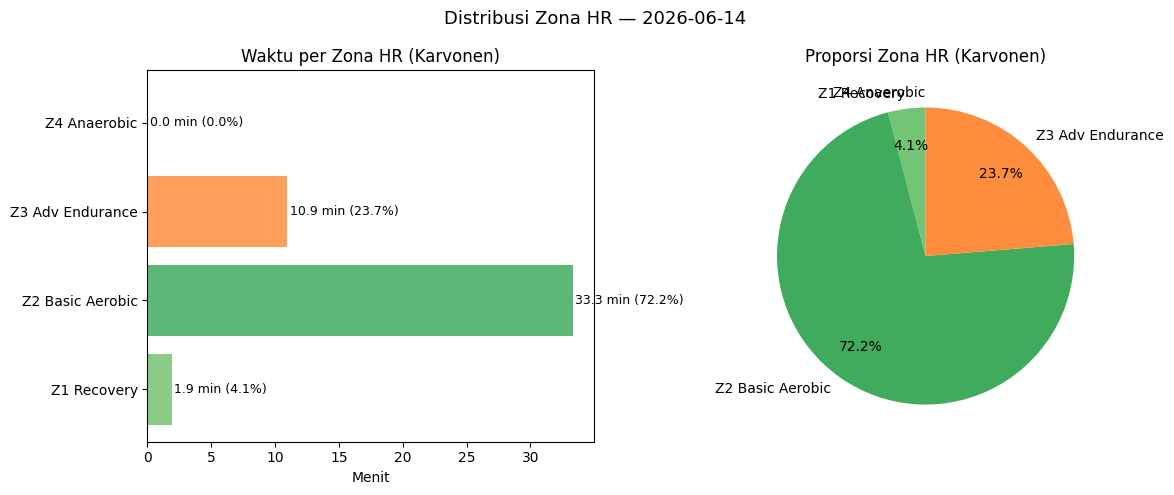


Ringkasan:
  Z1 Recovery           :   1.9 menit (4.1%)
  Z2 Basic Aerobic      :  33.3 menit (72.2%)
  Z3 Adv Endurance      :  10.9 menit (23.7%)
  Z4 Anaerobic          :   0.0 menit (0.0%)


In [8]:
NS = "{http://www.garmin.com/xmlschemas/TrackPointExtension/v1}"
hrs_all = df["hr"].dropna().values
total_s = len(hrs_all)

zona_names  = list(HR_ZONES.keys())
zona_ranges = list(HR_ZONES.values())
zona_colors = [HR_ZONE_COLORS[n] for n in zona_names]

zona_mins = []
zona_pcts = []
for (lo, hi) in zona_ranges:
    n = ((hrs_all >= lo) & (hrs_all < hi)).sum()
    zona_mins.append(n / 60)
    zona_pcts.append(n / total_s * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(zona_names, zona_mins, color=zona_colors, alpha=0.85)
axes[0].set_xlabel("Menit")
axes[0].set_title("Waktu per Zona HR (Karvonen)")
for i, (v, p) in enumerate(zip(zona_mins, zona_pcts)):
    axes[0].text(v + 0.2, i, f"{v:.1f} min ({p:.1f}%)", va="center", fontsize=9)

wedges, texts, autotexts = axes[1].pie(
    zona_pcts, labels=zona_names, colors=zona_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=90, pctdistance=0.75
)
axes[1].set_title("Proporsi Zona HR (Karvonen)")
fig.suptitle(f"Distribusi Zona HR — {run_date}", fontsize=13)
fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_zona_hr.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_zona_hr.png'}")
plt.show()

print("\nRingkasan:")
for name, mins, pct in zip(zona_names, zona_mins, zona_pcts):
    print(f"  {name:22s}: {mins:5.1f} menit ({pct:.1f}%)")

## 7. Prediksi Half Marathon (21.1km)

Ini bagian yang kamu minta — berapa lama HM di zona 2 penuh.
**Peringatan:** ini estimasi, bukan angka pasti. Ada beberapa asumsi yang aku labeli dengan jelas.

In [9]:
print("=" * 60)
print("PREDIKSI HALF MARATHON (21.1 km) — JUJUR & BERLAPIS")
print("=" * 60)

# Data dari lari hari ini
km_early   = splits_df[splits_df["km"] <= 3]
pace_start = km_early["pace"].mean()   # pace km 1-3 saat HR ~145
drift_total   = drift
drift_per_km  = drift / total_dist

print(f"\nData dasar dari lari hari ini ({total_dist:.1f}km):")
print(f"  Avg pace keseluruhan : {avg_pace:.2f} min/km")
print(f"  Pace km 1-3 (HR ~145): {pace_start:.2f} min/km")
print(f"  Cardiac drift        : {drift_total:+.1f} bpm ({drift_per_km:+.2f} bpm/km)")

# Metode 1: Riegel — dengan catatan jujur
t_hm_riegel = moving_min * (21.1 / total_dist) ** 1.06
print(f"\n--- METODE 1: Riegel (dari waktu {total_dist:.1f}km) ---")
print(f"  Estimasi HM : {t_hm_riegel:.0f} menit = {int(t_hm_riegel//60)}:{int(t_hm_riegel%60):02d}")
print(f"  ⚠️  OVEROPTIMIS — input adalah easy run, bukan race effort.")
print(f"     Anggap ini batas bawah yang tidak realistis untuk zona 2.")

# Metode 2: Pace zona 2 statis (tanpa koreksi drift)
z2_mask = (df["hr"] >= 140) & (df["hr"] < 152)
if z2_mask.sum() > 30:
    pace_z2 = df.loc[z2_mask, "pace_min_km"].clip(6, 14).median()
else:
    pace_z2 = pace_start * 1.05
t_hm_z2 = pace_z2 * 21.1
print(f"\n--- METODE 2: Pace zona 2 murni (tanpa koreksi drift) ---")
print(f"  Pace zona 2 tadi : {pace_z2:.2f} min/km")
print(f"  Estimasi HM      : {t_hm_z2:.0f} menit = {int(t_hm_z2//60)}:{int(t_hm_z2%60):02d}")
print(f"  ⚠️  Tidak realistis — asumsi HR tidak naik sepanjang 21km.")
print(f"     Drift-mu {drift_total:+.1f} bpm/10km berarti di km 20 HR sudah sangat tinggi.")

# Metode 3: Model realistis zona 2 dengan koreksi drift
# Untuk HM zona 2 murni: harus mulai konservatif supaya ada buffer drift
# Start pace ~8.80 (saat HR ~144), naikkan pace 0.08 min/km tiap 3km
print(f"\n--- METODE 3: Realistis — model zona 2 dengan drift koreksi ---")
pace_hm_start = pace_start  # 8.80 min/km saat HR ~145
total_time_sim = 0
print(f"  {'KM':>4}  {'Target Pace':>12}  {'Catatan'}")
for km in range(1, 22):
    slowdown = max(0, (km - 1) // 3) * 0.08  # +0.08 tiap 3km
    pace_km = pace_hm_start + slowdown
    total_time_sim += pace_km
    if km % 3 == 0 or km == 21:
        note = "(mulai konservatif)" if km <= 3 else ("(aktif slow down)" if km > 15 else "")
        print(f"  {km:>4}  {pace_km:>12.2f}  {note}")

avg_pace_hm = total_time_sim / 21
print(f"\n  Total waktu: {total_time_sim:.0f} menit = {int(total_time_sim//60)}:{int(total_time_sim%60):02d}")
print(f"  Avg pace HM: {avg_pace_hm:.2f} min/km")
print(f"  ✅ Ini estimasi paling realistis untuk zona 2 sepanjang 21.1km.")

t_hm_conservative = total_time_sim

print(f"\n{'='*60}")
print(f"RENTANG PREDIKSI HM:")
print(f"  Optimis  (Riegel, tidak realistis) : {int(t_hm_riegel//60)}:{int(t_hm_riegel%60):02d}")
print(f"  Moderat  (zona 2 statis)           : {int(t_hm_z2//60)}:{int(t_hm_z2%60):02d}")
print(f"  Realistis (koreksi drift)          : {int(t_hm_conservative//60)}:{int(t_hm_conservative%60):02d}")
print(f"{'='*60}")
print(f"\nPESAN JUJUR dari data lari hari ini:")
print(f"  Drift-mu +{drift_total:.1f} bpm dalam {total_dist:.0f}km = +1 bpm/km rata-rata.")
print(f"  Untuk HM zona 2 murni, 10km pertama HARUS terasa terlalu pelan")
print(f"  (target HR 143-147, bukan 150+) supaya ada buffer di km 11-21.")
print(f"  Kalau HR sudah di atas 152 di km 10, sisa 11km sangat susah dikendalikan.")
print(f"  Strategi konkret: km 1-7 target HR 143-147, baru naik perlahan setelahnya.")

PREDIKSI HALF MARATHON (21.1 km) — JUJUR & BERLAPIS

Data dasar dari lari hari ini (10.2km):
  Avg pace keseluruhan : 7.53 min/km
  Pace km 1-3 (HR ~145): 8.59 min/km
  Cardiac drift        : +10.3 bpm (+1.01 bpm/km)

--- METODE 1: Riegel (dari waktu 10.2km) ---
  Estimasi HM : 166 menit = 2:45
  ⚠️  OVEROPTIMIS — input adalah easy run, bukan race effort.
     Anggap ini batas bawah yang tidak realistis untuk zona 2.

--- METODE 2: Pace zona 2 murni (tanpa koreksi drift) ---
  Pace zona 2 tadi : 8.12 min/km
  Estimasi HM      : 171 menit = 2:51
  ⚠️  Tidak realistis — asumsi HR tidak naik sepanjang 21km.
     Drift-mu +10.3 bpm/10km berarti di km 20 HR sudah sangat tinggi.

--- METODE 3: Realistis — model zona 2 dengan drift koreksi ---
    KM   Target Pace  Catatan
     3          8.59  (mulai konservatif)
     6          8.67  
     9          8.75  
    12          8.83  
    15          8.91  
    18          8.99  (aktif slow down)
    21          9.07  (aktif slow down)

  Total 

## 8. Ringkasan Run Hari Ini

Tersimpan: ..\reports\2026\June\runs\2026-06-14_summary.png


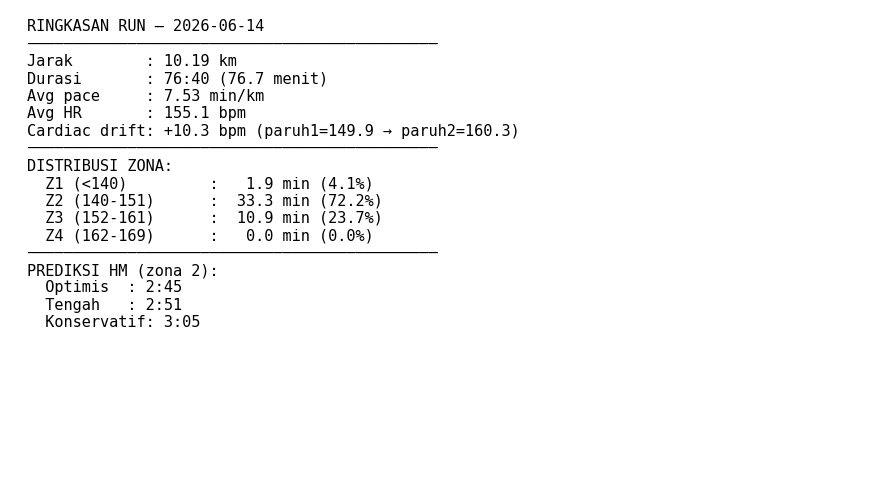

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")

# Data zona
z_labels = ["Z1 (<140)", "Z2 (140-151)", "Z3 (152-161)", "Z4 (162-169)", "Z5 (≥170)"]
z_mins = [round(m, 1) for m in zona_mins]
z_pcts = [round(p, 1) for p in zona_pcts]

sep = "─" * 45
txt = (
    f"RINGKASAN RUN — {run_date}\n"
    f"{sep}\n"
    f"Jarak        : {total_dist:.2f} km\n"
    f"Durasi       : {int(moving_min//1)}:{int((moving_min%1)*60):02d} ({moving_min:.1f} menit)\n"
    f"Avg pace     : {avg_pace:.2f} min/km\n"
    f"Avg HR       : {avg_hr:.1f} bpm\n"
    f"Cardiac drift: {drift:+.1f} bpm (paruh1={hr_first:.1f} → paruh2={hr_second:.1f})\n"
    f"{sep}\n"
    f"DISTRIBUSI ZONA:\n"
)
for zl, zm, zp in zip(z_labels, z_mins, z_pcts):
    txt += f"  {zl:18s}: {zm:5.1f} min ({zp:.1f}%)\n"
txt += (
    f"{sep}\n"
    f"PREDIKSI HM (zona 2):\n"
    f"  Optimis  : {int(t_hm_riegel//60)}:{int(t_hm_riegel%60):02d}\n"
    f"  Tengah   : {int(t_hm_z2//60)}:{int(t_hm_z2%60):02d}\n"
    f"  Konservatif: {int(t_hm_conservative//60)}:{int(t_hm_conservative%60):02d}"
)
ax.text(0.02, 0.98, txt, fontsize=11, family="monospace",
        verticalalignment="top", transform=ax.transAxes)
fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_summary.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_summary.png'}")
plt.show()